# SVM Exercises

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [ ]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE

Split data into training, colidation, and test sets with a test size of 25%

In [ ]:
# YOUR CODE HERE
X_cols = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

y_col = 'class'

data = pd.read_csv(url, names=names)
test_size = 0.25

X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)

# Further split X and y of training into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [ ]:
# Creating a model with sklearn's SVC
svm_high = SVC(gamma= 1, C=1)

# Training/fitting a model with training data
svm_high.fit(X_train, y_train)

SVC(C=1, gamma=1)

Print accuracy of training and validation data

In [ ]:
y_train_pred=svm_high.predict(X_train)
print("Training Accuracy is ", accuracy_score(y_train, y_train_pred)*100)
y_val_pred=svm_high.predict(X_val)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred)*100)

Training Accuracy is  100.0
Validation Accuracy is  61.80555555555556


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [ ]:
# Creating a model with sklearn's SVC
svm_low = SVC(gamma= 0.01, C=1)

# Training/fitting a model with training data
svm_low.fit(X_train, y_train)

SVC(C=1, gamma=0.01)

Print accuracy of training and validation data

In [ ]:
y_train_pred_high=svm_high.predict(X_train)
y_val_pred_high=svm_high.predict(X_val)
y_test_pred_high=svm_high.predict(X_test)

print("High gamma:\n")

print("Training Accuracy is ", accuracy_score(y_train, y_train_pred_high)*100)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred_high)*100)
print("Testing Accuracy is ", accuracy_score(y_test,y_test_pred_high)*100)

y_train_pred_low=svm_low.predict(X_train)
y_val_pred_low=svm_low.predict(X_val)
y_test_pred_low=svm_low.predict(X_test)

print("\nLow gamma:\n")

print("Training Accuracy is ", accuracy_score(y_train, y_train_pred_low)*100)
print("Validation Accuracy is ", accuracy_score(y_val,y_val_pred_low)*100)
print("Testing Accuracy is ", accuracy_score(y_test,y_test_pred_low)*100)



High gamma:

Training Accuracy is  100.0
Validation Accuracy is  61.80555555555556
Testing Accuracy is  67.70833333333334

Low gamma:

Training Accuracy is  98.8425925925926
Validation Accuracy is  64.58333333333334
Testing Accuracy is  68.22916666666666


Explain the accuracy results below.



```
# This is formatted as code
```

The model does not generalize very well, and it is overfitting.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

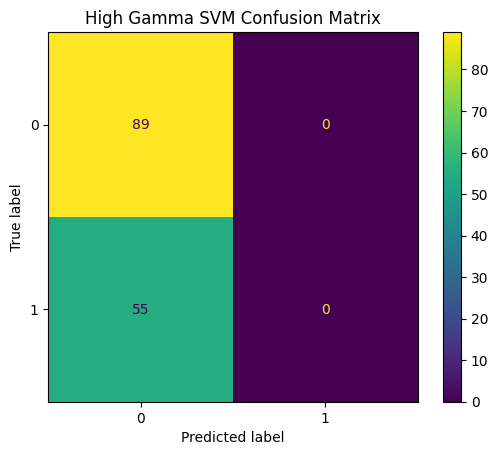

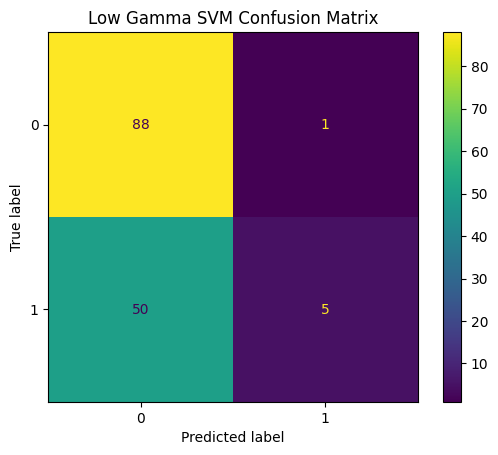

In [ ]:
# YOUR CODE HERE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_high = confusion_matrix(y_val, y_val_pred_high)
cm_low = confusion_matrix(y_val, y_val_pred_low)

disp_high = ConfusionMatrixDisplay(confusion_matrix=cm_high)
disp_low = ConfusionMatrixDisplay(confusion_matrix=cm_low)

disp_high.plot()
plt.title("High Gamma SVM Confusion Matrix")
disp_low.plot()
plt.title("Low Gamma SVM Confusion Matrix")
plt.show()
